In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Chargement et calculs de base
df = pd.read_csv("../../data/customers_clean.csv")

In [8]:
print(df.columns.tolist())

['customer_id', 'country', 'first_purchase', 'last_purchase', 'n_orders', 'total_spent', 'avg_basket', 'recency_days', 'tenure_days']


Corrélation entre récence et montant dépensé: est-elle linéaire ?


/tmp/ipykernel_26047/623210175.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='recency_group', y='total_spent', data=df, palette='viridis', estimator='mean', errorbar=None)


Nouveau graphique généré : analyse_recence_lineaire.png


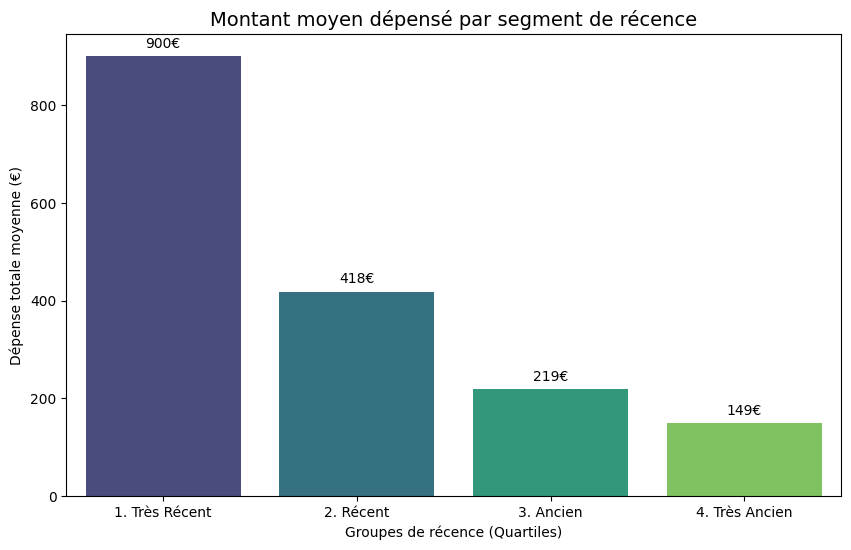

In [ ]:
df['recency_group'] = pd.qcut(df['recency_days'], q=4, labels=['1. Très Récent', '2. Récent', '3. Ancien', '4. Très Ancien'])

plt.figure(figsize=(10, 6))
sns.barplot(x='recency_group', y='total_spent', data=df, palette='viridis', estimator='mean', errorbar=None)

ax = plt.gca()
for p in ax.patches:
    ax.annotate(f'{p.get_height():.0f}€', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 9), textcoords='offset points')

#graph
plt.title("Montant moyen dépensé par segment de récence", fontsize=14)
plt.xlabel("Groupes de récence (Quartiles)")
plt.ylabel("Dépense totale moyenne (€)")

plt.savefig('analyse_recence_lineaire.png')
print("Nouveau graphique généré : analyse_recence_lineaire.png")

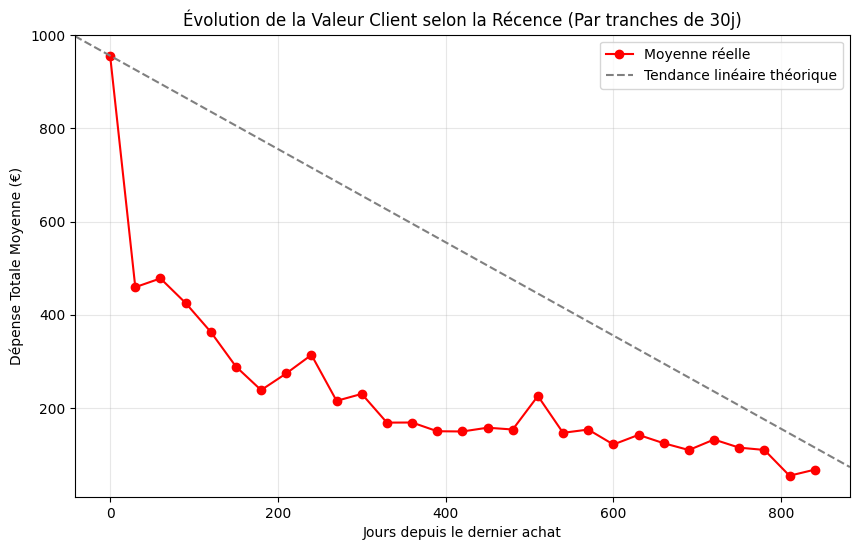

In [26]:
df['recency_bin'] = (df['recency_days'] // 30) * 30
trend = df.groupby('recency_bin')['total_spent'].mean().reset_index()

#graph
plt.figure(figsize=(10, 6))
plt.plot(trend['recency_bin'], trend['total_spent'], marker='o', linestyle='-', color='red', label='Moyenne réelle')
plt.axline((0, trend['total_spent'].iloc[0]), slope=-1, color='gray', linestyle='--', label='Tendance linéaire théorique')

plt.title("Évolution de la Valeur Client selon la Récence (Par tranches de 30j)")
plt.xlabel("Jours depuis le dernier achat")
plt.ylabel("Dépense Totale Moyenne (€)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.savefig('tendance_non_lineaire.png')

Relation entre fréquence et panier moyen: les clients fréquents dépensent-ils plus par visite ?

Graphique généré avec succès !


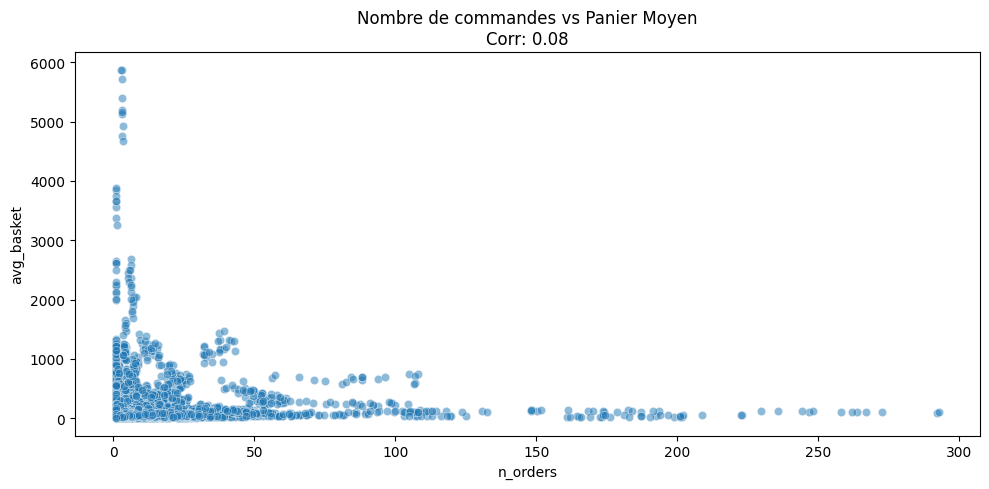

In [ ]:
df["recency"] = (pd.to_datetime("2024-06-01") - pd.to_datetime(df["last_purchase"])).dt.days

fig, axes = plt.subplots(1, 1, figsize=(10, 5))
sns.scatterplot(x='n_orders', y='avg_basket', data=df, ax=axes, alpha=0.5)
axes.set_title(f"Nombre de commandes vs Panier Moyen\nCorr: {df['n_orders'].corr(df['avg_basket']):.2f}")

plt.tight_layout()
plt.savefig('analyse_marketing_finale.png')
print("Graphique généré avec succès !")

Y a-t-il des segments "naturellement visibles" dans les données avant toute modélisation ?

In [21]:
df.head()

,customer_id,country,first_purchase,last_purchase,n_orders,total_spent,avg_basket,recency_days,tenure_days,recency,recency_group,segment_frequence,segment_recence
0,46995,United Kingdom,2011-08-09 12:20:00,2011-11-16 12:20:00,2.28,57.34,26.44,23.83,99.17,4580,1. Très Récent,2. Régulier (2-5),A. Récent (<30j)
1,22869,United Kingdom,2010-01-11 12:20:00,2011-10-30 12:20:00,46.53,19463.52,356.65,40.92,657.12,4597,2. Récent,3. Fidèle (5+),B. Tiède (30-90j)
2,12593,France,2011-05-05 09:29:00,2011-05-05 09:29:00,1.00,39.50,39.50,218.00,218.00,4775,3. Ancien,1. Occasionnel (1),C. Inactif (+90j)
3,25889,United Kingdom,2008-07-14 12:20:00,2010-02-22 12:20:00,0.98,24.53,25.15,655.23,588.26,5212,4. Très Ancien,1. Occasionnel (1),C. Inactif (+90j)
4,52931,United Kingdom,2009-08-29 12:20:00,2010-11-04 12:20:00,2.00,47.80,23.18,400.35,432.64,4957,3. Ancien,2. Régulier (2-5),C. Inactif (+90j)


In [22]:
df.describe()

,customer_id,n_orders,total_spent,avg_basket,recency_days,tenure_days,recency
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,38390.294040,4.746364,421.538510,65.428104,238.454858,482.477138,4795.073520
std,14517.833799,9.551931,2014.135812,139.874935,218.933454,224.947664,218.928316
min,12346.000000,0.850000,0.160000,0.160000,0.000000,0.000000,4557.000000
25%,25941.750000,1.060000,36.987500,21.787500,38.137500,343.822500,4595.000000
50%,38441.500000,2.220000,99.640000,38.810000,168.000000,532.980000,4725.000000
75%,50941.250000,5.210000,280.225000,69.100000,411.512500,662.260000,4968.000000
max,63441.000000,292.780000,69630.660000,5876.150000,844.590000,848.620000,5401.000000


Il y a des Prospects Actifs qu'il faut continuer de fidéliser. 
Ensuite on a des clients occasionnels qui passent de temps en temps mais il faut les chercher en faisant de l'activation passive (newsletter ou offre intéressante pour les faire revenir). 
Puis des clients fidèles qui se détache qu'il faut proposer des offres de réactivations.